<a href="https://colab.research.google.com/github/JorgeMoragaCalvo/data-science-playground/blob/main/lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import numpy as np
import sys
import time
import psutil
import matplotlib.pyplot as plt

t_cg = torch.manual_seed(1547)

In [ ]:
# torch.nn.Module es una clase base en PyTorch para todos los módulos de redes
# neuronales. Heredar de ella proporciona las funcionalidades necesarias
# para construir redes neuronales.
class FFNN(torch.nn.Module):
  # constructor de la clase FFNN con tres argumentos
  # d0: número de neuronas en la capa de entrada
  # d1: número de neuronas en la primera capa oculta
  # d2: número de neuronas en la segunda capa oculta
  def __init__(self, d0=300, d1=512, d2=256, weight_init='xavier', dropout_rate=0.3):
    """
        Red neuronal completamente conectada con inicialización de pesos configurable.

        Args:
            d0 (int): Dimensión de entrada.
            d1 (int): Dimensión de la primera capa oculta.
            d2 (int): Dimensión de la segunda capa oculta.
            weight_init (str): Método de inicialización de pesos ('xavier' o 'he').
    """
    # se llama al constructor de la clase padre torch.nn.Module
    super(FFNN, self).__init__()
    self.weight_init = weight_init
    # se crea una capa completamente conectada (lineal)
    # conecta la capa d0 con d1
    self.fc1 = torch.nn.Linear(d0, d1, bias=True)
    # Batch de NORMALIZACIÓN
    self.bn1 = torch.nn.BatchNorm1d(d1)
    self.dropout1 = torch.nn.Dropout(dropout_rate)
    # conecta la capa oculta d1 con d2
    self.fc2 = torch.nn.Linear(d1, d2, bias=True)
    self.bn2 = torch.nn.BatchNorm1d(d2)
    self.dropout2 = torch.nn.Dropout(dropout_rate)
    # conecta la capa oculta d2 con una única neurona de salida (1)
    self.fc3 = torch.nn.Linear(d2, 1, bias=True)

    # Inicialización de pesos
    if weight_init == 'xavier':
      torch.nn.init.xavier_uniform_(self.fc1.weight)
      torch.nn.init.xavier_uniform_(self.fc2.weight)
      torch.nn.init.xavier_uniform_(self.fc3.weight)
    elif weight_init == 'he':
      torch.nn.init.kaiming_uniform_(self.fc1.weight, nonlinearity='relu')
      torch.nn.init.kaiming_uniform_(self.fc2.weight, nonlinearity='relu')
      torch.nn.init.kaiming_uniform_(self.fc3.weight, nonlinearity='relu')
    else:
      raise ValueError('Función de inicialización no reconocida')


    # Se especifican cómo fluyen los datos a través de la red durante el
    # feed forward (predicción). "x" representa los datos de entrada
  def forward(self, x):
    # se pasa x a través de la primera capa
    u1 = self.fc1(x)
    # asigna la función de activación tanh() a u1, introduciendo no linealidad
    # y aplica Batch Normalization
    # h1 = torch.tanh(self.bn1(u1))
    u1 = self.bn1(u1)
    u1 = self.dropout1(u1) # Dropout
    #h1 = torch.tanh(u1)

    if self.weight_init == 'he':
      h1 = torch.relu(u1)
    else:
      h1 = torch.tanh(u1)

    # Segunda capa con BatchNorm, Dropout y activación
    u2 = self.fc2(u1)
    u2 = self.bn2(u2)
    u2 = self.dropout2(u2) # Dropout
    #h2 = torch.sigmoid(u2)

    if self.weight_init == 'he':
      h2 = torch.relu(u2)
    else:
      h2 = torch.sigmoid(u2)

    u3 = self.fc3(h2)
    # Se aplica sigmoide la capa de salida para producir una salida
    # entre 0 y 1
    y_pred = torch.sigmoid(u3)
    return y_pred

In [ ]:
from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler, TensorDataset
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
#from torch.vision import datasets, transforms

# Dataset es la clase base para todos los conjuntos de datos en PytTorch
# DataLoader se utiliza para iterar eficientemente sobre el conjunto de datos
# durante el entrenamiento

# Clase para crear un conjunto de datos personalizados. Hereda de Dataset
class RandomDataSet(Dataset):
  # N: número de puntos de datos en el conjunto de datos
  # f: número de características para cada punto de datos
  def __init__(self, N, f): # Constructor
    # se crea un tensor con valores aleatorios entre 0 y 1, con N filas y f col
    R_N_f = torch.rand(N, f)
    # Se crean los datos de entrada X con Bernoulli. Genera un tensor de 0s y 1s
    # donde cada elemento tiene una probabilidad de ser 1 igual al elemento
    # correspondiente en R_N_f
    self.X = torch.bernoulli(R_N_f)
    # Otro tensor aleatorio con N files y 1 columna
    R_N_1 = torch.rand(N, 1)
    self.Y = torch.bernoulli(R_N_1)
    # Se almacena el numero de características (f) como un atributo del
    # conjunto de datos
    self.num_features = f

  # Método para obtener el número total de puntos de datos en el conjunto de datos
  def __len__(self):
    # Devuelve el número de filas en el tensor de entrada x
    return self.X.size()[0]

  # Requerido por la clase Dataset, para acceder a un punto de datos específico
  # por su índice
  def __getitem__(self, i):
    return self.X[i], self.Y[i]

  # Código crea una clase de conjunto de datos personalizado
  # llamada RandomDataSet que genera datos binarios aleatorios para la
  # entrada (X) y la salida (Y).

class BreastCancerDataset(Dataset):
  def __init__(self):
    data = load_breast_cancer()
    X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)

    self.X = torch.tensor(X_train, dtype=torch.float32)
    self.Y = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

    self.num_features = data.data.shape[1]

  def __len__(self):
    return len(self.X)

  def __getitem__(self, i):
    return self.X[i], self.Y[i]

In [ ]:
# CELDA NUEVA 1
# BOOTSTRAP DATASETS
def create_bootstrap_samples(dataset, num_samples):
  bootstrap_datasets = []
  N = len(dataset)

  for _ in range(num_samples):
    indices = torch.randint(0, N, (N,))
    sampled_X = dataset.X[indices]
    sampled_Y = dataset.Y[indices]
    bootstrap_dataset = torch.utils.data.TensorDataset(sampled_X, sampled_Y)
    bootstrap_datasets.append(bootstrap_dataset)

  return bootstrap_datasets

In [ ]:
# Función de entrenamiento
"""
def loop_FFNN(dataset, batch_size, d1, d2, lr, epochs, optimizer_name, init_method='xavier',
              run_in_GPU=True, reports_every=1, cheq_grad=False, dropout_rate=0.3):
  # Determina si usar GPU o CPU
  device = 'cuda' if run_in_GPU else 'cpu'
  # número de características del dataset
  d0 = dataset.num_features
  # Crea una instancia del modelo FFNN con el tamaño de capaz especificadas
  net = FFNN(d0, d1, d2, init_method, dropout_rate=dropout_rate)
  # Mueve el modelo al dispositivo seleccionado
  net.to(device)
  print('Red: ', net)
  # Crea una DataLoader para iterar eficientemente sobre el 'dataset'
  # en el batches (batch_size) y desordena los datos
  # crea un objeto DataLoader que se encarga de dividir el conjunto de datos en
  #batches y de barajarlos antes de cada época. El argumento shuffle=True indica
  #que se debe realizar la aleatorización. Por lo tanto, en cada época, el
  # DataLoader seleccionará un conjunto diferente de ejemplos para formar los
  # batches, asegurando que el modelo se entrene con una variedad de datos en cada iteración.
  data = DataLoader(dataset, batch_size, shuffle=True)
  # Define una función de pérdida Binary Cross-Entropy Loss
  loss = torch.nn.BCELoss()
  # Configura el optimizador Stochastic Gradient Descent para actualizar
  # los parámetros del modelo con una tasa de aprendizaje lr
  # optimizer = torch.optim.SGD(net.parameters(), lr)

  if optimizer_name == 'SGD':
    optimizer = torch.optim.SGD(net.parameters(), lr, weight_decay=0.0001)
  elif optimizer_name == 'SGD_momentum':
    optimizer = torch.optim.SGD(net.parameters(), lr, momentum=0.9, weight_decay=0.0001)
  elif optimizer_name == 'SGD_nesterov':
    optimizer = torch.optim.SGD(net.parameters(), lr, momentum=0.9, nesterov=True, weight_decay=0.0001)
  elif optimizer_name == 'RMSprop':
    optimizer = torch.optim.RMSprop(net.parameters(), lr, alpha=0.99, weight_decay=0.0001)
  elif optimizer_name == 'Adam':
    optimizer = torch.optim.Adam(net.parameters(), lr, betas=(0.9, 0.999), weight_decay=0.0001)
  else:
    raise ValueError('Optimizador no reconocido')

  # Almacenar métricas
  losses = []
  accuracies = []

  # variable para registrar el tiempo total de entrenamiento
  epochs_time = 0
  #loop de entrenamiento
  for e in range(1, epochs+1):
    epoch_init = time.perf_counter()

    #net.train()

    # Se itera a través de los lotes de dato (x ,y) dentro de DataLoader
    for(x, y) in data:
      # Se mueven los datos al dispositivo seleccionado
      x = x.to(device)
      y = y.to(device)
      # Se realiza un recorrido hacia adelante a través del modelo para
      # obtener predicciones
      y_pred = net.forward(x)
      # Calcula la pérdida entre las predicciones y los objetivos reales
      L = loss(y_pred, y)

      # Término de regularización L2
      #l2_reg = sum(param.norm(2) ** 2 for param in net.parameters())
      #L_total = L + l2_lambda * l2_reg

      # Calcula gradientes de pérdidas con respecto a los parámetros
      # del modelo. Calcula los gradientes hacia atrás.
      L.backward()
      # Actualiza los parámetros del modelo basado en los gradientes calculados
      optimizer.step()
      # Restablece los gradientes a cero para la siguiente iteración
      optimizer.zero_grad()

    # Acumula el tiempo que toma cada iteración
    epochs_time += time.perf_counter() - epoch_init

    # Propósito: evaluar el rendimiento del modelo sobre todo el conjunto de datos
    if e % reports_every == 0:
      X = dataset.X.to(device)
      Y = dataset.Y.to(device)
      Y_PRED = net.forward(X)
      L_total = loss(Y_PRED, Y)
      #L_total_val = loss(Y_PRED, Y) + l2_lambda * sum(param.norm(2) ** 2 for param in net.parameters())
      Y_PRED_BIN = (Y_PRED > 0.5).float()
      correct = torch.sum(Y_PRED_BIN == Y).item()
      acc = (correct / N) * 100

      losses.append(L_total.item())
      #losses.append(L_total_val.item())
      accuracies.append(acc)

      sys.stdout.write(
          '\rEpoch:{0:03d}'.format(e) + ' Acc:{0:.2f}%'.format(acc)
          + ' Loss:{0:.4f}'.format(L_total)
          + ' Time/epoch:{0:.3f}s'.format(epochs_time/e))

  return losses, accuracies

#dataset.X: Un tensor de PyTorch de tamaño (5000, 300) que representa los datos de entrada.
Cada elemento de este tensor es 0 o 1, generado a partir de una distribución de Bernoulli.
#dataset.Y: Un tensor de PyTorch de tamaño (5000, 1) que representa las etiquetas
o salidas objetivo. Cada elemento también es 0 o 1, generado con Bernoulli.
#dataset.num_features: Un atributo que almacena el número de características,
en este caso, 300.

# En esencia, dataset representa un conjunto de datos aleatorio con 5000 ejemplos,
donde cada ejemplo tiene 300 características binarias (0 o 1) y una etiqueta binaria (0 o 1).
Se puede utilizar para entrenar y evaluar modelos de aprendizaje automático que trabajan con datos binarios.
"""

In [ ]:
# CELDA NUEVA 3 'early_stopping' y 'train_split' + Bootstrap
class EarlyStopping:
    def __init__(self, patience=5, delta=1e-5):
        self.patience = patience
        self.delta = delta
        self.best_loss = float('inf')
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

def loop_FFNN_ensemble(dataset, batch_size, d1, d2, lr, epochs, optimizer_name, init_method='xavier',
                        run_in_GPU=True, reports_every=1, cheq_grad=False, dropout_rate=0.3,
                        bootstrap_dataset=False, num_features=None):
    device = 'cuda' if run_in_GPU else 'cpu'
    d0 = num_features if num_features is not None else dataset.num_features # Modified to get d0 from num_features if provided
    net = FFNN(d0, d1, d2, init_method, dropout_rate=dropout_rate)
    net.to(device)
    print('Red: ', net)
    loss = torch.nn.BCELoss()

    if optimizer_name == 'SGD':
        optimizer = torch.optim.SGD(net.parameters(), lr, weight_decay=0.0001)
    elif optimizer_name == 'SGD_momentum':
        optimizer = torch.optim.SGD(net.parameters(), lr, momentum=0.9, weight_decay=0.0001)
    elif optimizer_name == 'SGD_nesterov':
        optimizer = torch.optim.SGD(net.parameters(), lr, momentum=0.9, nesterov=True, weight_decay=0.0001)
    elif optimizer_name == 'RMSprop':
        optimizer = torch.optim.RMSprop(net.parameters(), lr, alpha=0.99, weight_decay=0.0001)
    elif optimizer_name == 'Adam':
        optimizer = torch.optim.Adam(net.parameters(), lr, betas=(0.9, 0.999), weight_decay=0.0001)
    else:
      raise ValueError('Optimizador no reconocido')

    # División del conjunto de datos
    X, Y = dataset.tensors[0], dataset.tensors[1]
    X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)

    train_dataset = TensorDataset(X_train, Y_train)
    val_dataset = TensorDataset(X_val, Y_val)

    # Creación del DataLoader para el conjunto de validación
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Inicializar Early Stopping
    early_stopping = EarlyStopping(patience=5, delta=1e-5)

    losses = []
    val_losses = []
    accuracies = []

    epochs_time = 0
    N = len(train_dataset)

    for e in range(1, epochs + 1):
        epoch_init = time.perf_counter()

        if bootstrap_dataset:
            indices = np.random.choice(N, N, replace=True)
            sampler = SubsetRandomSampler(indices)
            train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler)
        else:
            train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

        net.train()
        for (x, y) in train_loader:
            x = x.to(device)
            y = y.to(device)
            y_pred = net.forward(x)
            L = loss(y_pred, y)
            L.backward()
            optimizer.step()
            optimizer.zero_grad()

        epochs_time += time.perf_counter() - epoch_init

        # Validación
        net.eval()
        val_loss = 0
        #
        correct = 0
        total = 0
        #
        with torch.no_grad():
            for (x_val, y_val) in val_loader:
                x_val = x_val.to(device)
                y_val = y_val.to(device)
                y_val_pred = net.forward(x_val)
                val_loss += loss(y_val_pred, y_val).item()

                #
                y_val_bin = (y_val_pred > 0.5).float()
                correct += (y_val_bin == y_val).sum().item()
                total += y_val.size(0)
                #

        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        # Calcular precisión de validación
        val_acc = (correct / total) * 100

        # Actualizar Early Stopping
        early_stopping(val_loss)
        if early_stopping.early_stop:
            print("Early stopping")
            break

        if e % reports_every == 0:
            X_train_deviced = X_train.to(device)
            Y_train_deviced = Y_train.to(device)
            Y_train_pred = net.forward(X_train_deviced)
            Y_train_bin = (Y_train_pred > 0.5).float()

            correct_train = (Y_train_bin == Y_train_deviced).sum().item()
            acc_train = (correct_train / N) * 100

            losses.append(val_loss)
            accuracies.append(acc_train)

            sys.stdout.write(
                '\rEpoch:{0:03d}'.format(e) + ' Acc:{0:.2f}%'.format(acc_train)
                + ' Val acc:{0:.2f}%'.format(val_acc)
                + ' Loss:{0:.4f}'.format(val_loss)
                + ' Time/epoch:{0:.3f}s'.format(epochs_time/e))

    return losses, val_losses, accuracies

In [ ]:
def run_experiments_ensemble(dataset, batch_size, d1, d2, lr, epochs, optimizers, init_methods, num_models=5, reports_every=1):
  results = {}
  bootstrap_datasets = create_bootstrap_samples(dataset, num_models)
  num_features = dataset.num_features

  for init in init_methods:
    for opt in optimizers:
      print(f"\n\nTraining with {opt} optimizer and {init} initialization...")
      for bootstrap_dataset in bootstrap_datasets:
        losses, val_losses, accuracies = loop_FFNN_ensemble(bootstrap_dataset, batch_size, d1, d2, lr, epochs, opt, run_in_GPU=False,
                                              reports_every=reports_every, cheq_grad=False, num_features=num_features)

        results[(opt, init)] = (losses, val_losses, accuracies)

  plot_results(results)

def plot_results(results):
  plt.figure(figsize=(12, 5))

  # Gráfica de pérdida
  plt.subplot(1, 2, 1)
  for (opt, init), (losses, val_losses, _) in results.items():
    plt.plot(losses, label=f'{opt}  ({init})')
  plt.title('Loss vs. Epochs')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()

  # Gráfica de precisión
  plt.subplot(1, 2, 2)
  for (opt, init), (_, _, accuracies) in results.items():
    plt.plot(accuracies, label=f'{opt}  ({init})')
  plt.title('Accuracy vs. Epochs')
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.legend()

  plt.tight_layout()
  plt.show()

In [ ]:
##################
# Activar N, f y RandomDataSet() para entrenar el dataset mencionado
N = 5000
f = 300
dataset = RandomDataSet(N, f)
##################

##################
# Activar para probar con el dataset BreastCancerDataset() y desactiva N, f, RandomDataSet()
#dataset = BreastCancerDataset()
#################

#optimizers = ['SGD', 'SGD_momentum', 'SGD_nesterov', 'RMSprop', 'Adam']
optimizers = ['Adam']
init_methods = ['xavier', 'he']



Training with Adam optimizer and xavier initialization...
Red:  FFNN(
  (fc1): Linear(in_features=300, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=256, out_features=1, bias=True)
)
Epoch:005 Acc:67.35% Val acc:58.80% Loss:0.6908 Time/epoch:0.541sEarly stopping
Red:  FFNN(
  (fc1): Linear(in_features=300, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.3, inpla

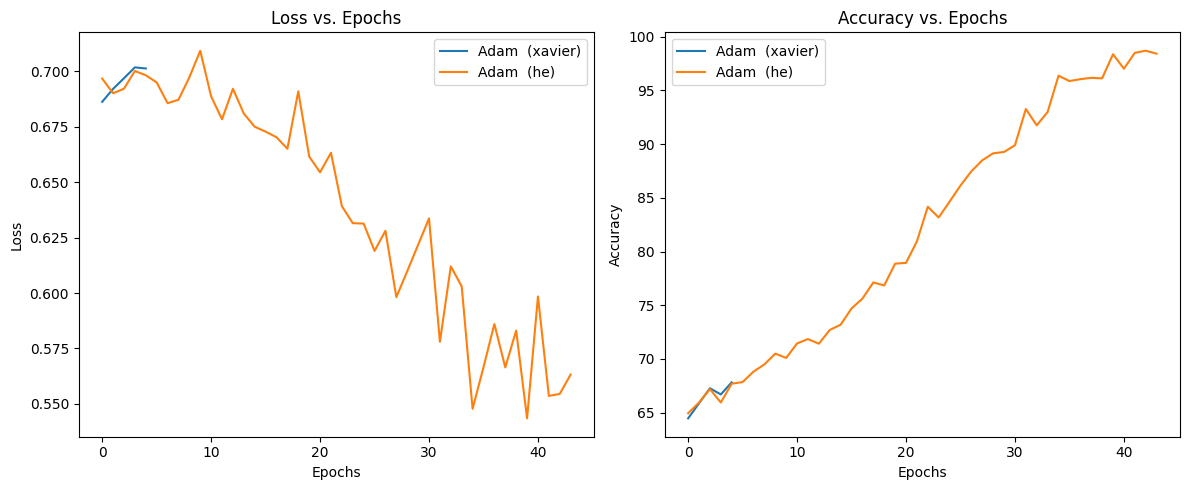

In [ ]:
epochs = 200


run_experiments_ensemble(dataset=dataset, batch_size=64, d1=512, d2=256, lr=0.001, epochs=epochs, optimizers=optimizers,
                init_methods=init_methods, num_models=5, reports_every=1)